In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026412.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000

In [2]:
!pip install -q torch torchvision mlflow dagshub \
    scikit-learn matplotlib seaborn pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

import mlflow
import mlflow.pytorch
import dagshub


In [4]:
dagshub.init(
    repo_owner="nazzzzzz096",
    repo_name="curamyn",
    mlflow=True
)

mlflow.set_experiment(
    "curamyn_skin_risk_cnn"
)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b6ad54bb-dd02-4925-b78a-73031e2c4d02&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=192f9837a5da88511cbb4a4e1a27c963fc30c74cc96b0cc4241c8d239df9190c




Accessing as nazzzzzz096

Initialized MLflow to track repo "nazzzzzz096/curamyn"

Repository nazzzzzz096/curamyn initialized!

2025/12/29 15:31:52 INFO mlflow.tracking.fluent: Experiment with name 'curamyn_skin_risk_cnn' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/08d70e23012e4cc49dd7880ce7de6867', creation_time=1767022312742, experiment_id='1', last_update_time=1767022312742, lifecycle_stage='active', name='curamyn_skin_risk_cnn', tags={}>

In [5]:
DATA_DIR = "/kaggle/input/skin-cancer-mnist-ham10000"

METADATA_PATH = os.path.join(
    DATA_DIR,
    "HAM10000_metadata.csv"
)


In [6]:
df = pd.read_csv(METADATA_PATH)
print("Total records:", len(df))
df.head()


Total records: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
BENIGN_CLASSES = {"nv", "vasc", "df"}

df["risk_label"] = df["dx"].apply(
    lambda x: 0 if x in BENIGN_CLASSES else 1
)

df["risk_label"].value_counts()


risk_label
0    6962
1    3053
Name: count, dtype: int64

In [11]:
num_normal = (df["risk_label"] == 0).sum()
num_risk = (df["risk_label"] == 1).sum()

pos_weight_value = num_normal / num_risk

print("Normal samples:", num_normal)
print("Risk samples:", num_risk)
print("Positive class weight:", round(pos_weight_value, 3))


Normal samples: 6962
Risk samples: 3053
Positive class weight: 2.28


In [12]:
image_paths = glob.glob(
    os.path.join(
        DATA_DIR,
        "HAM10000_images_part_*",
        "*.jpg"
    )
)

print("Images found:", len(image_paths))


Images found: 10015


In [13]:
image_path_map = {
    os.path.basename(path): path
    for path in image_paths
}

df["image_file"] = df["image_id"].apply(
    lambda x: f"{x}.jpg"
)

df = df[
    df["image_file"].isin(
        image_path_map.keys()
    )
].reset_index(drop=True)

print("After filtering:", len(df))


After filtering: 10015


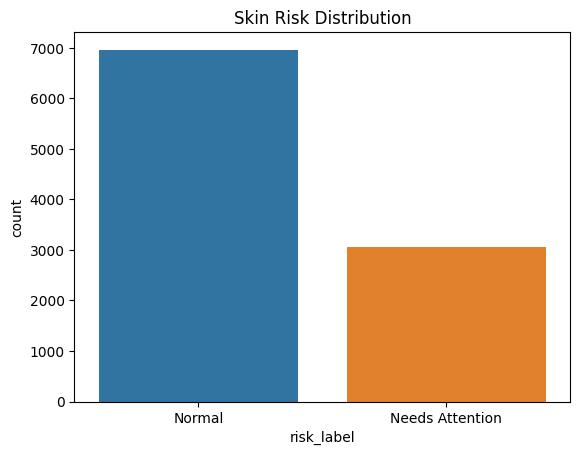

In [14]:
sns.countplot(x="risk_label", data=df)
plt.xticks([0, 1], ["Normal", "Needs Attention"])
plt.title("Skin Risk Distribution")
plt.show()


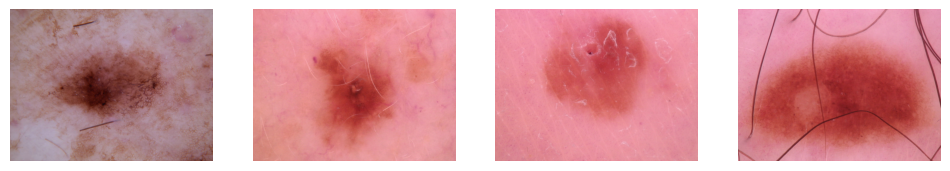

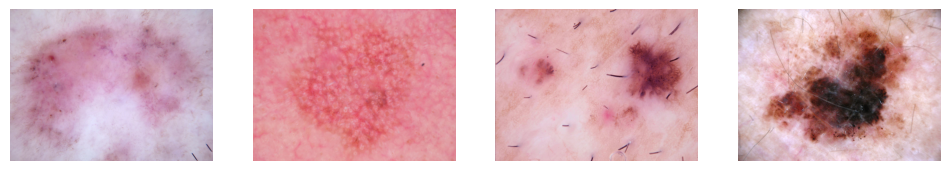

In [15]:
def show_samples(label, n=4):
    samples = df[
        df["risk_label"] == label
    ].sample(n)

    plt.figure(figsize=(12, 4))

    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(
            image_path_map[row["image_file"]]
        )
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()


show_samples(0)
show_samples(1)


In [16]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

train_size = int(0.8 * len(df))

train_df = df[:train_size]
val_df = df[train_size:]


In [17]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


In [18]:
class SkinDataset(Dataset):
    def __init__(self, dataframe, path_map, transform):
        self.dataframe = dataframe
        self.path_map = path_map
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = self.path_map[row["image_file"]]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        label = torch.tensor(
            row["risk_label"],
            dtype=torch.float32
        )

        return image, label


In [19]:
train_loader = DataLoader(
    SkinDataset(train_df, image_path_map, transform),
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    SkinDataset(val_df, image_path_map, transform),
    batch_size=32,
    shuffle=False,
    num_workers=2
)


In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)


Using device: cuda


In [21]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s] 


In [22]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        pos_weight_value,
        device=device
    )
)


optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)


In [23]:
def train_epoch(model, loader):
    model.train()
    losses = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)


In [24]:
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).squeeze()
            probs = torch.sigmoid(outputs)

            preds.extend(probs.cpu().numpy())
            targets.extend(labels.numpy())

    bin_preds = [1 if p >= 0.5 else 0 for p in preds]

    return {
        "accuracy": accuracy_score(targets, bin_preds),
        "recall": recall_score(targets, bin_preds),
        "roc_auc": roc_auc_score(targets, preds),
    }


In [25]:
EPOCHS = 5

with mlflow.start_run():
    mlflow.log_param("model", "resnet18")
    mlflow.log_param("task", "skin_binary_risk")
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("pos_weight", round(pos_weight_value, 3))

    for epoch in range(EPOCHS):
        loss = train_epoch(model, train_loader)
        metrics = evaluate(model, val_loader)

        print(
            f"Epoch {epoch + 1} | "
            f"Loss: {loss:.4f} | "
            f"Recall: {metrics['recall']:.4f}"
        )

    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    mlflow.pytorch.log_model(
        model,
        artifact_path="skin_risk_model"
    )


Epoch 1 | Loss: 0.6362 | Recall: 0.8308
Epoch 2 | Loss: 0.5685 | Recall: 0.8275
Epoch 3 | Loss: 0.5526 | Recall: 0.8408
Epoch 4 | Loss: 0.5524 | Recall: 0.7496
Epoch 5 | Loss: 0.5434 | Recall: 0.8325


2025/12/29 15:52:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/29 15:52:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/29 15:52:42 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run judicious-squid-617 at: https://dagshub.com/nazzzzzz096/curamyn.mlflow/#/experiments/1/runs/662607da498f485798370c7a2a1056bc
🧪 View experiment at: https://dagshub.com/nazzzzzz096/curamyn.mlflow/#/experiments/1


Prediction: normal
Confidence: 0.25


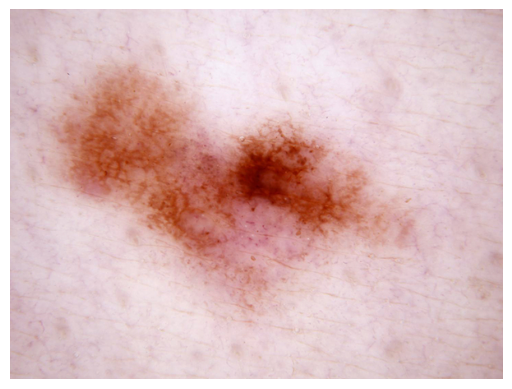

In [26]:
model.eval()

row = val_df.sample(1).iloc[0]
img_path = image_path_map[row["image_file"]]

image = Image.open(img_path)
plt.imshow(image)
plt.axis("off")

with torch.no_grad():
    img_tensor = transform(image)\
        .unsqueeze(0)\
        .to(device)

    prob = torch.sigmoid(
        model(img_tensor)
    ).item()


THRESHOLD = 0.4  # better recall for risk screening

risk = (
    "needs_attention"
    if prob >= THRESHOLD
    else "normal"
)

print("Prediction:", risk)
print("Confidence:", round(prob, 3))


In [27]:
MODEL_PATH = "/kaggle/working/skin_risk_resnet18.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": "resnet18",
        "task": "skin_binary_risk",
        "threshold": 0.5
    },
    MODEL_PATH
)

MODEL_PATH


'/kaggle/working/skin_risk_resnet18.pt'